# Importação das Bibliotecas Utilizadas

In [1]:
!pip install keras_tuner

In [2]:
import keras_tuner as kt
import math
import matplotlib.pyplot as plt
import numpy as np
import random
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import tensorflow as tf
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.formula.api import ols
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# Obtenção da Equação para a Taxa de Reação (k)

## Inserção da Matriz Experimental do Processo UVC/H2O2

In [3]:
planejamento_fatorial = pd.DataFrame(
    {
        'Experimento': range(1,12),
        'Concentração Inicial EE2 (mg/L)': [2.0, 8.0, 2.0, 8.0, 2.0, 8.0, 2.0, 8.0, 5.0, 5.0, 5.0],
        'Concentração Inicial H2O2 (mg/L)': [45.88, 45.88, 68.82, 68.82, 45.88, 45.88, 68.82, 68.82, 57.35, 57.35, 57.35],
        'Irradiância (W/m2)': [8.0, 8.0, 8.0, 8.0, 17.9, 17.9, 17.9, 17.9, 14.6, 14.6, 14.6],
        'k (min-1)': [0.0282, 0.0090, 0.0276, 0.0128, 0.0672, 0.0279, 0.0664, 0.0332, 0.0269, 0.0348, 0.0353]
    }
)

planejamento_fatorial

,Experimento,Concentração Inicial EE2 (mg/L),Concentração Inicial H2O2 (mg/L),Irradiância (W/m2),k (min-1)
0,1,2.0,45.88,8.0,0.0282
1,2,8.0,45.88,8.0,0.0090
2,3,2.0,68.82,8.0,0.0276
3,4,8.0,68.82,8.0,0.0128
4,5,2.0,45.88,17.9,0.0672
5,6,8.0,45.88,17.9,0.0279
6,7,2.0,68.82,17.9,0.0664
7,8,8.0,68.82,17.9,0.0332
8,9,5.0,57.35,14.6,0.0269
9,10,5.0,57.35,14.6,0.0348


In [4]:
matriz_codificada = pd.DataFrame()

matriz_codificada['Experimento'] = planejamento_fatorial['Experimento']
matriz_codificada['EE2'] = planejamento_fatorial['Concentração Inicial EE2 (mg/L)'].apply(lambda x: -1 if x == 2.0 else (1 if x == 8.0 else 0))
matriz_codificada['H2O2'] = planejamento_fatorial['Concentração Inicial H2O2 (mg/L)'].apply(lambda x: -1 if x == 45.88 else (1 if x == 68.82 else 0))
matriz_codificada['EUVC'] = planejamento_fatorial['Irradiância (W/m2)'].apply(lambda x: -1 if x == 8.0 else (1 if x == 17.9 else 0))
matriz_codificada['k'] = planejamento_fatorial['k (min-1)']

matriz_codificada


,Experimento,EE2,H2O2,EUVC,k
0,1,-1,-1,-1,0.0282
1,2,1,-1,-1,0.0090
2,3,-1,1,-1,0.0276
3,4,1,1,-1,0.0128
4,5,-1,-1,1,0.0672
5,6,1,-1,1,0.0279
6,7,-1,1,1,0.0664
7,8,1,1,1,0.0332
8,9,0,0,0,0.0269
9,10,0,0,0,0.0348


## Construção do Modelo OLS com Análise de Variância (ANOVA)

In [5]:
formula_k = 'k ~ EE2 * H2O2 * EUVC'

modelo_k = ols(formula=formula_k, data=matriz_codificada).fit()

anova_resultados = sm.stats.anova_lm(modelo_k, typ=1)

print('=' * 50)
print('TABELA ANOVA - SIGNIFICÂNCIA ESTATÍSTICA')
print('=' * 50)
print(anova_resultados)
print('\n' + '=' * 50)
print('COEFICIENTES DO MODELO DE REGRESSÃO - k (min-1)')
print('=' * 50)
print(modelo_k.summary())

TABELA ANOVA - SIGNIFICÂNCIA ESTATÍSTICA
                df        sum_sq       mean_sq           F    PR(>F)
EE2            1.0  1.417781e-03  1.417781e-03   83.821178  0.002755
H2O2           1.0  7.411250e-06  7.411250e-06    0.438163  0.555315
EE2:H2O2       1.0  1.378125e-05  1.378125e-05    0.814766  0.433247
EUVC           1.0  1.714051e-03  1.714051e-03  101.337068  0.002087
EE2:EUVC       1.0  1.852813e-04  1.852813e-04   10.954082  0.045403
H2O2:EUVC      1.0  2.112500e-07  2.112500e-07    0.012489  0.918075
EE2:H2O2:EUVC  1.0  3.612500e-07  3.612500e-07    0.021358  0.893077
Residual       3.0  5.074307e-05  1.691436e-05         NaN       NaN

COEFICIENTES DO MODELO DE REGRESSÃO - k (min-1)
                            OLS Regression Results                            
Dep. Variable:                      k   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:

# Simulação de Monte Carlo para expansão da base de dados

## Definição das variáveis do processo

### Variáveis de processo

In [6]:
EE2_inferior = 2.0 #mg/L
EE2_superior = 8.0 #mg/L
H2O2_inferior = 45.88 #mg/L
H2O2_superior = 68.82 #mg/L
irradiancia_lampadas = [8.0, 14.6, 17.9] #W/m2

### Variáveis de simulação

In [7]:
numero_simulacoes = 100000
random_seed = 42

In [8]:
# Ajustes para reprodutibilidade

random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)
tf.config.experimental.enable_op_determinism()

## Simulação de Monte Carlo

In [9]:
EE2_simulacoes = np.random.uniform(EE2_inferior, EE2_superior, numero_simulacoes)
H2O2_simulacoes = np.random.uniform(H2O2_inferior, H2O2_superior, numero_simulacoes)
EUVC_simulacoes = np.random.choice(irradiancia_lampadas, size=numero_simulacoes)

In [10]:
massa_removida_EE2 = EE2_simulacoes * 0.99 * 0.150

massa_removida_EE2

array([0.63071525, 1.14408645, 0.9492066 , ..., 0.89793799, 0.74200749,
       0.64440846])

In [11]:
EE2_codificado = (EE2_simulacoes - 5.0) / 3.0
H2O2_codificado = (H2O2_simulacoes - 57.35) / 11.47
EUVC_codificado = np.where(EUVC_simulacoes == 8.0, -1, np.where(EUVC_simulacoes == 17.9, 1, 0))

In [12]:
k_predito = (
    0.0336
    - 0.0133 * EE2_codificado
    + 0.0010 * H2O2_codificado
    + 0.0146 * EUVC_codificado
    + 0.0013 * EE2_codificado * H2O2_codificado
    - 0.0048 * EE2_codificado * EUVC_codificado
    + 0.0002 * H2O2_codificado * EUVC_codificado
    + 0.0002 * EE2_codificado * H2O2_codificado * EUVC_codificado
)

k_predito

array([0.02121747, 0.02172816, 0.02695133, ..., 0.0408239 , 0.0485869 ,
       0.0513183 ])

In [13]:
# Adição de Ruído Estocástico (Incerteza Experimental)
ruido = np.random.normal(0, math.sqrt(1.691436e-05), numero_simulacoes)
k_simulado = k_predito + ruido

# Filtrar eventuais k negativos ou muito próximos de zero gerados pelo ruído
# (Fisicamente impossível e quebra o logaritmo)
k_simulado = np.clip(k_simulado, 0.001, None)

k_simulado

array([0.0165598 , 0.02263578, 0.03170337, ..., 0.045866  , 0.0496343 ,
       0.05785021])

## Cálculo do GWP

In [14]:
#Cálculo do tempo de reação para atingir 99% de remoção do EE2 (em horas)

tempo_reacao = (-(np.log(0.01))/k_simulado) / 60

tempo_reacao

array([4.63488846, 3.39077556, 2.42096762, ..., 1.67341463, 1.546367  ,
       1.32675111])

In [15]:
# Estimativa GWP H2O2 (kg CO2-eq) para cada simulação

volume_H2O2 = (H2O2_simulacoes * 0.150) / 321288.5
massa_H2O2 = (H2O2_simulacoes * volume_H2O2) / 1e06
gwp_H2O2 = massa_H2O2 * 1.28

gwp_H2O2

array([2.09456828e-09, 2.00813828e-09, 1.73824818e-09, ...,
       1.51131391e-09, 2.21357605e-09, 1.25988277e-09])

In [16]:
# Estimativa GWP das lâmpadas (kg CO2-eq) para cada simulação

lampadas_simulacoes = np.where(EUVC_simulacoes == 8.0, 2, np.where(EUVC_simulacoes == 17.9, 4, 3))
gwp_producao_lampadas = (tempo_reacao/6000) * lampadas_simulacoes * 1.12
gwp_uso_lampadas = 8 * tempo_reacao * lampadas_simulacoes * 0.000162
gwp_lampadas = gwp_producao_lampadas + gwp_uso_lampadas

gwp_lampadas

array([0.01374399, 0.01508217, 0.01076846, ..., 0.00992446, 0.00917099,
       0.00786852])

In [17]:
# Estimativa GWP do agitador (kg CO2-eq) para cada simulação

gwp_agitador = 650 * tempo_reacao * 0.000162

gwp_agitador

array([0.48805375, 0.35704867, 0.25492789, ..., 0.17621056, 0.16283245,
       0.13970689])

In [18]:
# Estimativa GWP do banho termostático (kg CO2-eq) para cada simulação

gwp_banho_termostatico = 500 * tempo_reacao * 0.000162

gwp_banho_termostatico

array([0.37542597, 0.27465282, 0.19609838, ..., 0.13554659, 0.12525573,
       0.10746684])

In [19]:
# Estimativa GWP total do processo (kg CO2-eq) para cada simulação

gwp_total = gwp_H2O2 + gwp_lampadas + gwp_agitador + gwp_banho_termostatico

gwp_total

array([0.87722371, 0.64678366, 0.46179473, ..., 0.32168161, 0.29725916,
       0.25504225])

## Geração do Banco de Dados

In [20]:
df_simulado = pd.DataFrame({
    'Concentração inicial EE2 (mg/L)': EE2_simulacoes,
    'Concentração inicial H2O2 (mg/L)': H2O2_simulacoes,
    'EUVC (W/m²)': EUVC_simulacoes,
    'k (min-1)': k_simulado,
    'Tempo de Reação (h)': tempo_reacao,
    'GWP Total (kg CO2-eq)': gwp_total,
    'Massa Removida EE2 (mg)': massa_removida_EE2
})

df_simulado

,Concentração inicial EE2 (mg/L),Concentração inicial H2O2 (mg/L),EUVC (W/m²),k (min-1),Tempo de Reação (h),GWP Total (kg CO2-eq),Massa Removida EE2 (mg)
0,4.247241,59.203071,8.0,0.016560,4.634888,0.877224,0.630715
1,7.704286,57.968730,14.6,0.022636,3.390776,0.646784,1.144086
2,6.391964,53.932788,14.6,0.031703,2.420968,0.461795,0.949207
3,5.591951,57.194298,17.9,0.051946,1.477547,0.284030,0.830405
4,2.936112,54.255317,14.6,0.039843,1.926360,0.367449,0.436013
...,...,...,...,...,...,...,...
99995,6.753829,60.152120,14.6,0.024239,3.166508,0.604005,1.002944
99996,6.675517,60.314318,14.6,0.027159,2.826007,0.539055,0.991314
99997,6.046720,50.289152,17.9,0.045866,1.673415,0.321682,0.897938
99998,4.996683,60.861717,17.9,0.049634,1.546367,0.297259,0.742007


In [21]:
tamanho_original = len(df_simulado)
df_simulado = df_simulado[df_simulado['Tempo de Reação (h)'] <= 8.53]
tamanho_novo = len(df_simulado)

print(f'Foram removidas {tamanho_original - tamanho_novo} simulações com tempos fisicamente irreais')

Foram removidas 2060 simulações com tempos fisicamente irreais


## Exportação da base de dados em formato CSV

In [22]:
df_simulado.to_excel('Banco de Dados UVC_H2O2.xlsx', index=False)

In [23]:
df_simulado.describe()

,Concentração inicial EE2 (mg/L),Concentração inicial H2O2 (mg/L),EUVC (W/m²),k (min-1),Tempo de Reação (h),GWP Total (kg CO2-eq),Massa Removida EE2 (mg)
count,97940.000000,97940.000000,97940.000000,97940.000000,97940.000000,97940.000000,97940.000000
mean,4.950090,57.423145,13.612763,0.034171,2.773555,0.527887,0.735088
std,1.714685,6.620535,4.084759,0.014580,1.412587,0.266123,0.254631
min,2.000033,45.880110,8.000000,0.008999,0.980512,0.188484,0.297005
25%,3.464975,51.688048,8.000000,0.022439,1.735869,0.332439,0.514549
50%,4.941928,57.459338,14.600000,0.032444,2.365699,0.452003,0.733876
75%,6.416344,63.143495,17.900000,0.044216,3.420586,0.649214,0.952827
max,7.999952,68.819756,17.900000,0.078278,8.528889,1.614223,1.187993


# Treinamento da rede neural

## Divisão de dados em treino/teste

In [24]:
x = df_simulado[['Concentração inicial EE2 (mg/L)', 'Concentração inicial H2O2 (mg/L)', 'EUVC (W/m²)']]
y_k = df_simulado['k (min-1)']
y_gwp = df_simulado['GWP Total (kg CO2-eq)']

x_train, x_test, y_k_train, y_k_test, y_gwp_train, y_gwp_test = train_test_split(x, y_k, y_gwp, test_size=0.2, random_state= random_seed)

print(x_train.shape, x_test.shape, y_k_train.shape, y_k_test.shape, y_gwp_train.shape, y_gwp_test.shape)

(78352, 3) (19588, 3) (78352,) (19588,) (78352,) (19588,)


## Normalização dos dados de entrada (x)

In [25]:
scaler_x = StandardScaler()
x_train_scaled = scaler_x.fit_transform(x_train)
x_test_scaled = scaler_x.transform(x_test)

print(x_train_scaled)
print(x_test_scaled)

[[ 0.65197484  1.5930737   1.04809056]
 [-0.21637933  0.80544891  0.2404112 ]
 [ 1.35351317  1.61632561  0.2404112 ]
 ...
 [-1.03539121 -0.19312527 -1.37494753]
 [ 0.5645288   0.87954124 -1.37494753]
 [-0.67999175  0.77052749  1.04809056]]
[[-0.40153921  0.72301079 -1.37494753]
 [ 1.4891728  -1.44952937 -1.37494753]
 [ 1.26016663  0.27125775  0.2404112 ]
 ...
 [ 0.3866918   0.09844011 -1.37494753]
 [-0.80897636  0.1946985  -1.37494753]
 [-0.97943107 -0.60125925 -1.37494753]]


## Normalização dos dados de saída (y)

In [26]:
scaler_y_k = StandardScaler()
scaler_y_gwp = StandardScaler()

y_k_train_scaled = scaler_y_k.fit_transform(y_k_train.values.reshape(-1, 1))
y_k_test_scaled = scaler_y_k.transform(y_k_test.values.reshape(-1, 1))

y_gwp_train_scaled = scaler_y_gwp.fit_transform(y_gwp_train.values.reshape(-1, 1))
y_gwp_test_scaled = scaler_y_gwp.transform(y_gwp_test.values.reshape(-1, 1))

print(y_k_train_scaled)
print(y_k_test_scaled)
print(y_gwp_train_scaled)
print(y_gwp_test_scaled)

[[ 0.85155888]
 [-0.26691036]
 [-0.89017221]
 ...
 [-0.87886517]
 [-1.22002125]
 [ 1.02908886]]
[[-1.03143603]
 [-1.72027729]
 [-0.97649781]
 ...
 [-0.82093207]
 [-0.56334801]
 [-0.93425649]]
[[-0.7927319 ]
 [-0.16748356]
 [ 0.60997867]
 ...
 [ 0.57000726]
 [ 1.34475321]
 [-0.85520372]]
[[0.86665079]
 [4.01692903]
 [0.77359737]
 ...
 [0.47295069]
 [0.11794161]
 [0.67027293]]


## Arquitetura da Rede Neural

In [27]:
def build_model(hp):
    tf.keras.utils.set_random_seed(random_seed)

    inputs = layers.Input(shape=(3,), name = "variaveis_entrada")

    # Grid Search para o número de neurônios na primeira camada oculta
    hp_units_1 = hp.Choice('units_1', values=[32, 64, 128])
    x = layers.Dense(units=hp_units_1, activation='relu', name = "camada_oculta_1")(inputs)

    # Grid Search para o número de neurônios na segunda camada oculta
    hp_units_2 = hp.Choice('units_2', values=[16, 32, 64])
    x = layers.Dense(units=hp_units_2, activation='relu', name = "camada_oculta_2")(x)

    saida_k = layers.Dense(1, name = "saida_k")(x)
    saida_gwp = layers.Dense(1, name = "saida_gwp")(x)

    model = models.Model(inputs=inputs, outputs=[saida_k, saida_gwp])

    # Grid Search para a taxa de aprendizado
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss={'saida_k': 'mean_squared_error', 'saida_gwp': 'mean_squared_error'},
        loss_weights={'saida_k': 1.0, 'saida_gwp': 1.0},
    )

    return model

### Configuração do Keras Tuner

In [28]:
tuner = kt.GridSearch(
    build_model,
    objective = 'val_loss',
    max_trials = 27,
    directory="tcc_tuner",
    project_name="UVC_H2O2_tuning",
    seed = random_seed,
    overwrite = True
)

tuner.search_space_summary()

Search space summary
Default search space size: 3
units_1 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
units_2 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


### Execução do GridSearch

In [29]:
early_stop_tuner = EarlyStopping(monitor='val_loss', patience=10)

tuner.search(
    x_train_scaled,
    {'saida_k': y_k_train, 'saida_gwp': y_gwp_train},
    epochs = 50,
    validation_split = 0.2,
    callbacks = [early_stop_tuner],
    verbose = 1
)

Trial 27 Complete [00h 05m 39s]
val_loss: 0.013103587552905083

Best val_loss So Far: 0.013039423152804375
Total elapsed time: 01h 35m 23s


### Obtenção dos melhores hiperparâmetros do modelo

In [30]:
melhores_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n" + "="*50)
print("MELHORES HIPERPARÂMETROS ENCONTRADOS PELA OTIMIZAÇÃO:")
print("="*50)
print(f"Neurônios Camada 1: {melhores_hp.get('units_1')}")
print(f"Neurônios Camada 2: {melhores_hp.get('units_2')}")
print(f"Taxa de Aprendizado (LR): {melhores_hp.get('learning_rate')}")
print("="*50)


MELHORES HIPERPARÂMETROS ENCONTRADOS PELA OTIMIZAÇÃO:
Neurônios Camada 1: 32
Neurônios Camada 2: 16
Taxa de Aprendizado (LR): 0.0001


### Implementação dos melhores hiperparâmetros no modelo de Rede Neural

In [31]:
modelo_rede_final = tuner.hypermodel.build(melhores_hp)

## Treinamento da Rede

### Configuração do Early Stopping

In [32]:
early_stop_final = EarlyStopping(
    monitor = 'val_loss',
    patience = 20,
    restore_best_weights = True,
    verbose = 1
    )

### Fit da Rede

In [33]:
rede_final = modelo_rede_final.fit(
    x_train_scaled,
    {'saida_k': y_k_train_scaled, 'saida_gwp': y_gwp_train_scaled},
    validation_split = 0.2,
    epochs = 300,
    batch_size = 128,
    callbacks = [early_stop_final],
    verbose = 1
)

print("Treinamento da Rede Neural Finalizado.")

Epoch 1/300
490/490 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.4281 - saida_gwp_loss: 0.8214 - saida_k_loss: 0.6062 - val_loss: 0.7979 - val_saida_gwp_loss: 0.5025 - val_saida_k_loss: 0.2960
Epoch 2/300
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4960 - saida_gwp_loss: 0.3097 - saida_k_loss: 0.1862 - val_loss: 0.3373 - val_saida_gwp_loss: 0.2077 - val_saida_k_loss: 0.1298
Epoch 3/300
490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3059 - saida_gwp_loss: 0.1957 - saida_k_loss: 0.1101 - val_loss: 0.2854 - val_saida_gwp_loss: 0.1888 - val_saida_k_loss: 0.0966
Epoch 4/300
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2802 - saida_gwp_loss: 0.1883 - saida_k_loss: 0.0919 - val_loss: 0.2731 - val_saida_gwp_loss: 0.1858 - val_saida_k_loss: 0.0874
Epoch 5/300
490/490 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2730 - saida_gwp_loss: 0.1869 - saida_k_loss: 0.0860 - val_loss: 0.2682 - val_saida_gwp_loss: 0.1851 - val_saida_k_loss: 0.0832
Epoch 6/300
490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 3

## Avaliação do Histórico de Treinamento

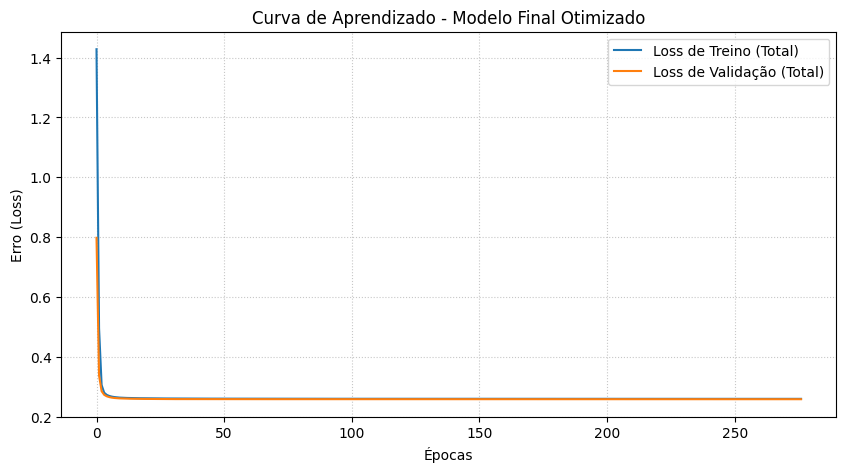

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(rede_final.history['loss'], label='Loss de Treino (Total)')
plt.plot(rede_final.history['val_loss'], label='Loss de Validação (Total)')
plt.title('Curva de Aprendizado - Modelo Final Otimizado')
plt.xlabel('Épocas')
plt.ylabel('Erro (Loss)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## Avaliação da rede no conjunto de teste sintético

In [35]:
previsoes_teste_scaled = modelo_rede_final.predict(x_test_scaled)

k_previsto_teste = scaler_y_k.inverse_transform(previsoes_teste_scaled[0]).flatten()
gwp_previsto_teste = scaler_y_gwp.inverse_transform(previsoes_teste_scaled[1]).flatten()

613/613 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [36]:
print("Desempenho do Modelo Final nos Dados de Teste para k:")
print(f"R²: {r2_score(y_k_test, k_previsto_teste):.4f}")
print(f"MAE: {mean_absolute_error(y_k_test, k_previsto_teste):.6f}")
print(f"MSE: {mean_squared_error(y_k_test, k_previsto_teste):.6f}")
print(f"MAPE: {mean_absolute_percentage_error(y_k_test, k_previsto_teste):.2f}%")

Desempenho do Modelo Final nos Dados de Teste para k:
R²: 0.9222
MAE: 0.003225
MSE: 0.000016
MAPE: 0.12%


In [37]:
print("Desempenho do Modelo Final nos Dados de Teste para GWP:")
print(f"R²: {r2_score(y_gwp_test, gwp_previsto_teste):.4f}")
print(f"MAE: {mean_absolute_error(y_gwp_test, gwp_previsto_teste):.6f}")
print(f"MSE: {mean_squared_error(y_gwp_test, gwp_previsto_teste):.6f}")
print(f"MAPE: {mean_absolute_percentage_error(y_gwp_test, gwp_previsto_teste):.2f}%")

Desempenho do Modelo Final nos Dados de Teste para GWP:
R²: 0.8183
MAE: 0.069709
MSE: 0.012630
MAPE: 0.12%


## Visualização dos Resultados: Real vs. Predito

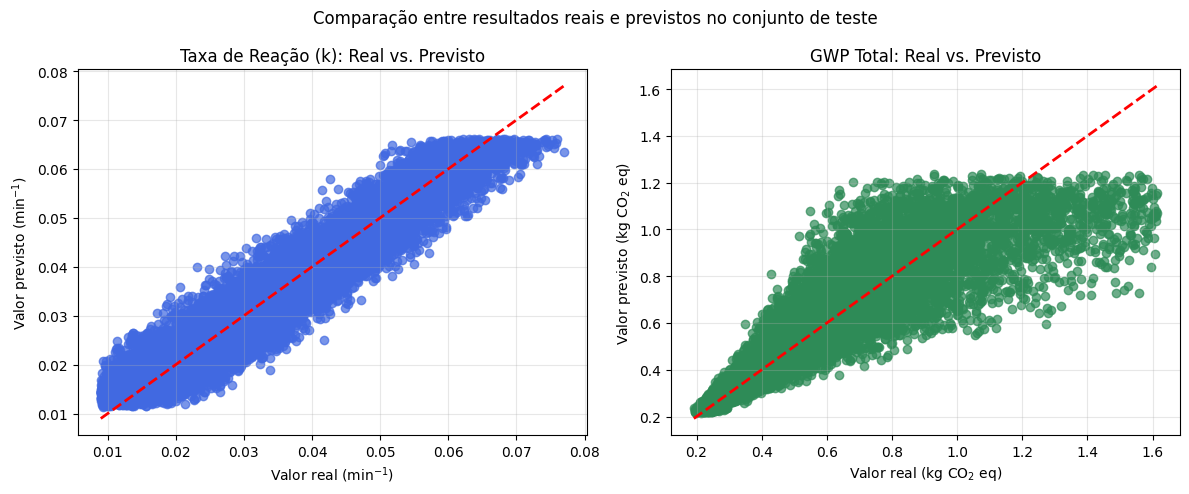

In [38]:
# Valores reais e previstos do conjunto de teste
k_real = np.asarray(y_k_test).ravel()
k_previsto = np.asarray(k_previsto_teste).ravel()
gwp_real = np.asarray(y_gwp_test).ravel()
gwp_previsto = np.asarray(gwp_previsto_teste).ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Constante de velocidade (k)
limites_k = [min(k_real.min(), k_previsto.min()), max(k_real.max(), k_previsto.max())]
axes[0].scatter(k_real, k_previsto, alpha=0.7, color='royalblue')
axes[0].plot(limites_k, limites_k, 'r--', linewidth=2)
axes[0].set_title('Taxa de Reação (k): Real vs. Previsto')
axes[0].set_xlabel('Valor real (min$^{-1}$)')
axes[0].set_ylabel('Valor previsto (min$^{-1}$)')
axes[0].grid(True, alpha=0.3)

# GWP total
limites_gwp = [min(gwp_real.min(), gwp_previsto.min()), max(gwp_real.max(), gwp_previsto.max())]
axes[1].scatter(gwp_real, gwp_previsto, alpha=0.7, color='seagreen')
axes[1].plot(limites_gwp, limites_gwp, 'r--', linewidth=2)
axes[1].set_title('GWP Total: Real vs. Previsto')
axes[1].set_xlabel('Valor real (kg CO$_2$ eq)')
axes[1].set_ylabel('Valor previsto (kg CO$_2$ eq)')
axes[1].grid(True, alpha=0.3)

fig.suptitle('Comparação entre resultados reais e previstos no conjunto de teste')
fig.tight_layout()
plt.show()

## Avaliação da rede com os dados de bancada

In [39]:
matriz_reduzida = matriz_codificada[:8]
matriz_reduzida['GWP'] = [0.516, 1.620, 0.527, 1.140, 0.220, 0.531, 0.223, 0.446]
matriz_reduzida

/tmp/ipykernel_155940/3639990657.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matriz_reduzida['GWP'] = [0.516, 1.620, 0.527, 1.140, 0.220, 0.531, 0.223, 0.446]


,Experimento,EE2,H2O2,EUVC,k,GWP
0,1,-1,-1,-1,0.0282,0.516
1,2,1,-1,-1,0.0090,1.620
2,3,-1,1,-1,0.0276,0.527
3,4,1,1,-1,0.0128,1.140
4,5,-1,-1,1,0.0672,0.220
5,6,1,-1,1,0.0279,0.531
6,7,-1,1,1,0.0664,0.223
7,8,1,1,1,0.0332,0.446


In [40]:
x_bancada_scaled = matriz_reduzida[['EE2', 'H2O2', 'EUVC']]
y_k_bancada = matriz_reduzida['k']
y_gwp_bancada = matriz_reduzida['GWP']

x_bancada_scaled

,EE2,H2O2,EUVC
0,-1,-1,-1
1,1,-1,-1
2,-1,1,-1
3,1,1,-1
4,-1,-1,1
5,1,-1,1
6,-1,1,1
7,1,1,1


In [41]:
previsoes_bancada_scaled = modelo_rede_final.predict(x_bancada_scaled)

k_previsto_bancada = scaler_y_k.inverse_transform(previsoes_bancada_scaled[0]).flatten()
gwp_previsto_bancada = scaler_y_gwp.inverse_transform(previsoes_bancada_scaled[1]).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


In [42]:
print("Desempenho do Modelo Final nos Dados de Teste para k:")
print(f"R²: {r2_score(y_k_bancada, k_previsto_bancada):.4f}")
print(f"MAE: {mean_absolute_error(y_k_bancada, k_previsto_bancada):.6f}")
print(f"MSE: {mean_squared_error(y_k_bancada, k_previsto_bancada):.6f}")
print(f"MAPE: {mean_absolute_percentage_error(y_k_bancada, k_previsto_bancada):.2f}%")

Desempenho do Modelo Final nos Dados de Teste para k:
R²: 0.8937
MAE: 0.006010
MSE: 0.000044
MAPE: 0.27%


In [43]:
print("Desempenho do Modelo Final nos Dados de Teste para GWP:")
print(f"R²: {r2_score(y_gwp_bancada, gwp_previsto_bancada):.4f}")
print(f"MAE: {mean_absolute_error(y_gwp_bancada, gwp_previsto_bancada):.6f}")
print(f"MSE: {mean_squared_error(y_gwp_bancada, gwp_previsto_bancada):.6f}")
print(f"MAPE: {mean_absolute_percentage_error(y_gwp_bancada, gwp_previsto_bancada):.2f}%")

Desempenho do Modelo Final nos Dados de Teste para GWP:
R²: 0.6986
MAE: 0.151057
MSE: 0.061679
MAPE: 0.18%


## Visualização dos Resultados: Bancada vs. Predito

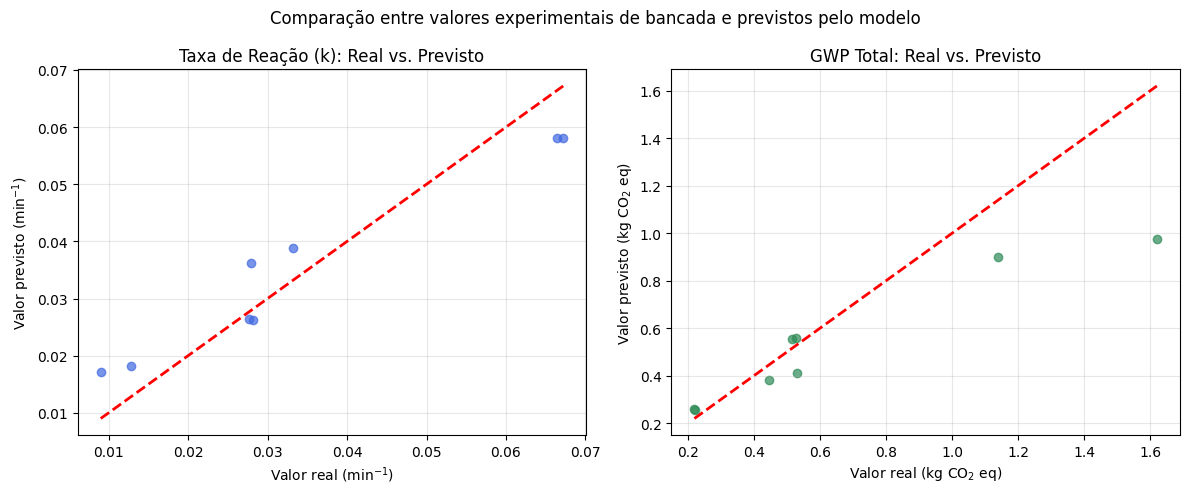

In [44]:
# Valores reais e previstos do conjunto de teste
k_real = np.asarray(y_k_bancada).ravel()
k_previsto = np.asarray(k_previsto_bancada).ravel()
gwp_real = np.asarray(y_gwp_bancada).ravel()
gwp_previsto = np.asarray(gwp_previsto_bancada).ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Constante de velocidade (k)
limites_k = [min(k_real.min(), k_previsto.min()), max(k_real.max(), k_previsto.max())]
axes[0].scatter(k_real, k_previsto, alpha=0.7, color='royalblue')
axes[0].plot(limites_k, limites_k, 'r--', linewidth=2)
axes[0].set_title('Taxa de Reação (k): Real vs. Previsto')
axes[0].set_xlabel('Valor real (min$^{-1}$)')
axes[0].set_ylabel('Valor previsto (min$^{-1}$)')
axes[0].grid(True, alpha=0.3)

# GWP total
limites_gwp = [min(gwp_real.min(), gwp_previsto.min()), max(gwp_real.max(), gwp_previsto.max())]
axes[1].scatter(gwp_real, gwp_previsto, alpha=0.7, color='seagreen')
axes[1].plot(limites_gwp, limites_gwp, 'r--', linewidth=2)
axes[1].set_title('GWP Total: Real vs. Previsto')
axes[1].set_xlabel('Valor real (kg CO$_2$ eq)')
axes[1].set_ylabel('Valor previsto (kg CO$_2$ eq)')
axes[1].grid(True, alpha=0.3)

fig.suptitle('Comparação entre valores experimentais de bancada e previstos pelo modelo')
fig.tight_layout()
plt.show()